Esercitazione pratica: implementa un classificatore binario per un dataset con 30 feature. Crea una struttura con 3 layer densi (32,16,1 neuroni). Configura il modello con l'ottimizzatore 'Adam' e la perdita 'binary_crossentropy'. Prima di lanciare il training, analizza il summary e calcola manualmente perchè il primo layer ha il numero di parametri visualizzato.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [17]:
#1. PREPARAZIONE DEI DATI
X,y=make_classification(
        n_samples=1000
        , n_features=30
        ,n_informative=5
        ,n_redundant=25
        , random_state=42
    )
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42) 
#20% viene tenuto da parte per li test,  80% per il training

In [18]:
#2.DEFINIZIONE ARCHITETTURA
model=Sequential([
    Input(shape=(30,)),  #n. di feature, il primo layer deve gestire correttamente la dimensionalità dei dati
    Dense(32,activation='relu',name='Hidden_Layer_1'), #64 neuroni, attivazione relu (la più veloce)
    Dropout(0.2), #ad ogni addestramento spegne il 20% dei neuroni, per evitare che alcuni neuroni correggono altri neuroni
    Dense(16,activation='relu',name='Hidden_Layer_2'), #relu standard per layer nascosti
    Dense(1,activation='sigmoid',name='Output_Layer') #straot finale con un singolo neurone, perchè è un problema di classificazione binaria (o 0 o 1)
])

In [19]:
#3.COMPILAZIONE
model.compile(
    optimizer='adam', #ottimizzatore adam, gestisce autoottimizzazione di ogni neurone, per quanto riguarda il passo ma in generale anche tutti gli altri aspetto di calcolo delle derivata
    loss='binary_crossentropy', #binary_crossentropy classica di un problema di classificazione binaria
    metrics=['accuracy'] #target
)

In [20]:
#4.ISPEZIONE
model.summary() #per vedere come è costruito il modello

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer_1 (Dense)          │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer_2 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
#5.ADDESTRAMENTO
print("Inizio addestramento...")
#Salviamo l'output di fit nella variabile history per poter tracciare i grafici
history=model.fit(X_train, y_train,
                    epochs=50, #n. di epoche, aumentare leggermente per vedere meglio l'andamento
                    batch_size=32, #velocizza il calcolo e lo rende migliore
                    validation_split=0.2, #il 20% del train per la validazione live dei singoli modelli, ad ogni addestramento il modello ha dati per calcolare l'errore, da utilizzarsi per la valutazione
                    verbose=1)

Inizio addestramento...
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.5297 - loss: 0.8954 - val_accuracy: 0.6375 - val_loss: 0.5965
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6781 - loss: 0.5709 - val_accuracy: 0.8188 - val_loss: 0.4647
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7844 - loss: 0.4835 - val_accuracy: 0.8687 - val_loss: 0.4011
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8313 - loss: 0.4332 - val_accuracy: 0.9000 - val_loss: 0.3436
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8656 - loss: 0.3654 - val_accuracy: 0.9125 - val_loss: 0.2999
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8734 - loss: 0.3431 - val_accuracy: 0.9125 - val_loss: 0.2723
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8828 - loss: 0.3254 - val_accuracy: 0.9125 - val_loss: 0.2473
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8766 - loss: 0.3046 - val_acc

In [22]:
#6.VALUTAZIONE FINALE
loss,acc=model.evaluate(X_test,y_test,verbose=0)
print(f"Accuratezza finale sul Test set: {acc:.4f}")

Accuratezza finale sul Test set: 0.9550


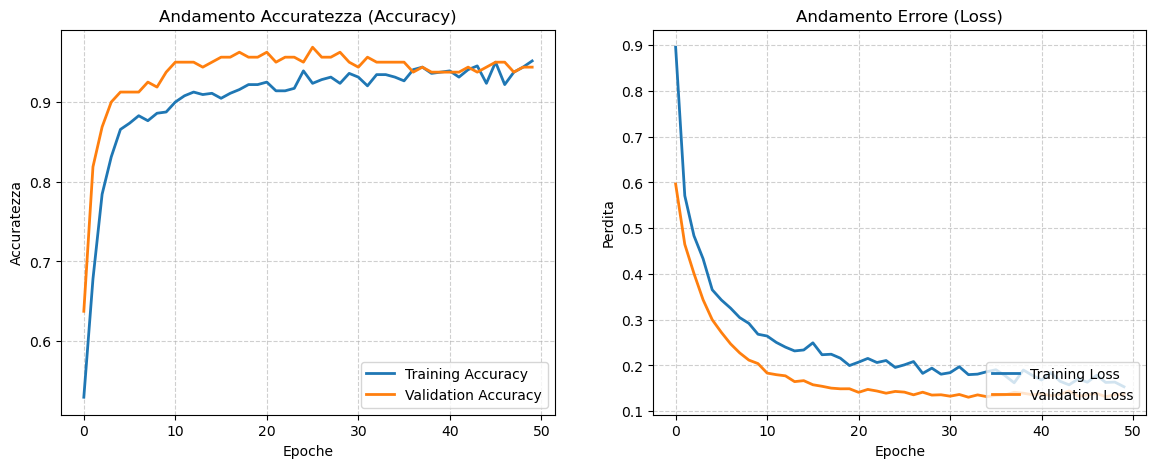

In [23]:
#7.VISUALIZZAZIONE DELLE CURVE DI APPRENDIMENTO
#Creiamo una figura con due grafici (uno per la loss e uno per l'accuratezza)
plt.figure(figsize=(14,5))

#GRAFICO ACCURACY
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy',color='#1f77b4',linewidth=2)
plt.plot(history.history['val_accuracy'],label='Validation Accuracy',color='#ff7f0e',linewidth=2)
plt.title('Andamento Accuratezza (Accuracy)')
plt.xlabel('Epoche')
plt.ylabel('Accuratezza')
plt.legend(loc='lower right')
plt.grid(True,linestyle='--',alpha=0.6)

#GRAFICO ACCURACY
plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Training Loss',color='#1f77b4',linewidth=2)
plt.plot(history.history['val_loss'],label='Validation Loss',color='#ff7f0e',linewidth=2)
plt.title('Andamento Errore (Loss)')
plt.xlabel('Epoche')
plt.ylabel('Perdita')
plt.legend(loc='lower right')
plt.grid(True,linestyle='--',alpha=0.6)

plt.show()